# Phase mixing y Landau damping con autogravedad

Todo lo anterior se hizo con el fondo isócrono fijo, donde $J$ es una constante
exacta del movimiento y existe una respuesta cerrada contra la que comparar. Aquí
se enciende la gravedad de las propias partículas.

**El montaje.** La distribución gaussiana de siempre,
$F_0 \propto e^{-\sin^2(Q/2)/\sigma_Q^2}\,e^{-J^2/\sigma_J^2} J^2$, con masa total
$a_0 = 10^{-3}$, es decir **una milésima de la masa del isócrono**. El fondo isócrono
sigue ahí y la autogravedad entra como perturbación encima, de modo que las variables
ángulo-acción del isócrono siguen siendo una descripción útil. $N = 10^4$ partículas,
yoshida4 con $\Delta t = 0.1$, hasta $t = 2000$, unos 20 periodos orbitales.

Se corrieron los **dos esquemas de muestreo**, Monte Carlo y cuadratura, uno después
del otro. Y un **control sin autogravedad** con todo lo demás idéntico, porque sin él
no hay forma de atribuir nada: cualquier cosa que aparezca hay que poder compararla
con lo que habría pasado sin la gravedad propia.

In [1]:
import os, numpy as np, h5py
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi':120,'font.size':9,'axes.grid':True,'grid.alpha':.25})

DATA = '../../exe/sg'
assert os.path.isdir(DATA), os.path.abspath(DATA)

def leer(d):
    a = np.loadtxt(os.path.join(DATA, d, 'hk1_complex.tl'))
    t = a[:,0]
    h = np.array([a[:,1+2*k] + 1j*a[:,2+2*k] for k in range(5)])
    return t, h

RUNS = {'sin autogravedad':'quad_nosg', 'autogravedad, cuadratura':'quad',
        'autogravedad, Monte Carlo':'mc'}
T, H = {}, {}
for k, d in RUNS.items():
    T[k], H[k] = leer(d)
print('Frecuencia orbital en el pico de la distribucion:')
c = 0.5*(2 + np.sqrt(8)); Jp = 0.1
om0 = 1/(Jp+c)**3; omp = -3/(Jp+c)**4
print(f'   omega = {om0:.5f}   periodo = {2*np.pi/om0:.1f}   |domega/dJ| = {abs(omp):.5f}')

Frecuencia orbital en el pico de la distribucion:
   omega = 0.06292   periodo = 99.9   |domega/dJ| = 0.07508


/home/erik/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Salud numérica antes de interpretar nada

Con el fondo fijo el integrador es simpléctico y la energía se conserva a precisión
de máquina. Al encender la autogravedad eso deja de ser cierto: la fuerza sale de una
densidad depositada en malla y no deriva exactamente de un hamiltoniano, así que el
esquema **ya no es simpléctico**. Conviene saber a qué nivel, porque fija el suelo por
debajo del cual no hay que creerse nada.

In [2]:
print(f"{'corrida':>26} {'deriva de E':>13} {'deriva de h_0':>15}")
for k, d in RUNS.items():
    f = h5py.File(os.path.join(DATA, d, 'vlasov_output.h5'))
    st = sorted([s for s in f if s.startswith('step_')], key=lambda s:int(s.split('_')[1]))
    e0 = float(f[st[0]].attrs['total_energy']); e1 = float(f[st[-1]].attrs['total_energy'])
    h0 = H[k][0].real
    print(f'{k:>26} {abs(e1/e0-1):>13.2e} {h0[-1]/h0[0]-1:>+15.3e}')

                   corrida   deriva de E   deriva de h_0
          sin autogravedad      7.01e-11      -2.443e-10
  autogravedad, cuadratura      4.96e-04      -1.602e-02
 autogravedad, Monte Carlo      4.99e-04      -1.602e-02


Dos cosas, y la segunda es el primer resultado físico:

**La energía** se conserva a $7\times10^{-11}$ sin autogravedad y a $5\times10^{-4}$ con
ella. Ese $5\times10^{-4}$ es el suelo de confianza de estas corridas.

**$h_0$ deriva un $-1.6\%$**, treinta veces más que el error de energía, y *exactamente
lo mismo en los dos esquemas de muestreo*. No es ruido ni error de integración: es
física. $h_0$ mide $\langle b(J)\rangle$, y sólo es constante mientras $J$ lo sea. Al
añadir el potencial propio, $\delta\Phi \sim a_0/r \sim 2\times10^{-4}$ frente a
$|\Phi_{\rm iso}|\sim 0.086$, las energías orbitales se desplazan y con ellas las
acciones. **La deriva de $h_0$ es la medida directa de cuánto deja de conservarse $J$.**

Sin autogravedad la misma cantidad se conserva a $2\times10^{-10}$, que es el control
que permite afirmar lo anterior.

## 2. ¿Phase mixing o Landau damping? Lo dice la forma de la envolvente

Es la distinción que se puede zanjar con los datos, sin ambigüedad:

- **Phase mixing puro.** $h_k(t)=C\int dJ\,g(J)\,e^{-ik\omega(J)t}$. Linealizando
  $\omega\simeq\omega_0+\omega'(J-J_0)$ sobre una $g$ gaussiana de anchura $\sigma_J$,
  la integral da $\;|h_k|\propto \exp[-(k\,|\omega'|\,\sigma_J\,t)^2/4]$: una
  **gaussiana en $t$**. En escala logarítmica, una parábola.

- **Landau damping.** El amortiguamiento colectivo de un modo es
  $|h_k|\propto e^{-\gamma t}$: una **exponencial**. En escala logarítmica, una recta.

Así que basta ajustar $\log|h_1|$ contra $t^2$ y contra $t$ y ver cuál de los dos
describe los datos.

In [3]:
print(f"{'corrida':>26} {'R^2 frente a t^2':>17} {'R^2 frente a t':>16}   veredicto")
coef = {}
for k in RUNS:
    t, h = T[k], np.abs(H[k][1])
    m = (t > 0) & (t < 250) & (h > 0)          # tramo de decaimiento inicial
    y = np.log(h[m])
    r2 = np.corrcoef(t[m]**2, y)[0,1]**2
    r1 = np.corrcoef(t[m],    y)[0,1]**2
    coef[k] = np.polyfit(t[m]**2, y, 1)[0]
    print(f'{k:>26} {r2:>17.5f} {r1:>16.5f}   '
          f'{"gaussiana: phase mixing" if r2 > r1 else "exponencial: Landau"}')

                   corrida  R^2 frente a t^2   R^2 frente a t   veredicto
          sin autogravedad           1.00000          0.93781   gaussiana: phase mixing
  autogravedad, cuadratura           0.99861          0.93752   gaussiana: phase mixing
 autogravedad, Monte Carlo           0.99859          0.93808   gaussiana: phase mixing


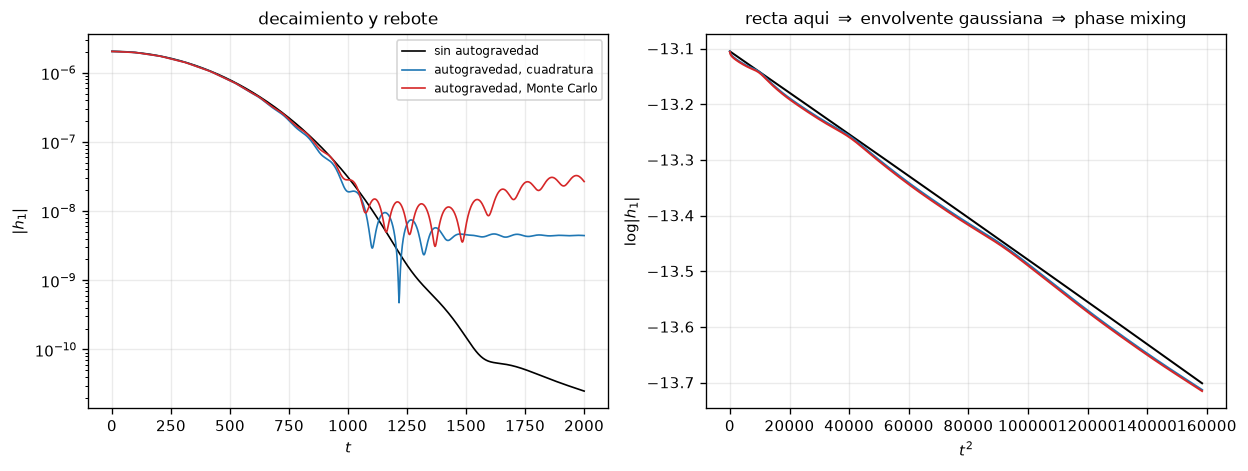

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
col = {'sin autogravedad':'k', 'autogravedad, cuadratura':'tab:blue',
       'autogravedad, Monte Carlo':'tab:red'}
for k in RUNS:
    t, h = T[k], np.abs(H[k][1])
    axes[0].semilogy(t, h, lw=1, color=col[k], label=k)
    m = t < 400
    axes[1].plot(t[m]**2, np.log(h[m]), lw=1.2, color=col[k], label=k)
axes[0].set_xlabel('$t$'); axes[0].set_ylabel('$|h_1|$')
axes[0].set_title('decaimiento y rebote', fontsize=10); axes[0].legend(fontsize=7)
axes[1].set_xlabel('$t^2$'); axes[1].set_ylabel(r'$\log|h_1|$')
axes[1].set_title('recta aqui $\\Rightarrow$ envolvente gaussiana $\\Rightarrow$ phase mixing',
                  fontsize=10)
fig.tight_layout()

**El decaimiento inicial es phase mixing, no Landau damping.** El ajuste gaussiano da
$R^2 = 1.00000$ sin autogravedad, y el exponencial $0.938$. En el panel derecho los
datos caen sobre una recta frente a $t^2$, que es la firma de la mezcla de fases.

Tiene sentido: con $a_0=10^{-3}$ la autogravedad es una perturbación del 0.1%, y el
amortiguamiento de Landau es un efecto colectivo que necesita que el campo propio sea
comparable al de fondo. Aquí no lo es. Lo que domina es cinemática pura: las órbitas
tienen frecuencias distintas y la estructura angular se enrolla.

In [5]:
b0 = coef['sin autogravedad']; b1 = coef['autogravedad, cuadratura']
b2 = coef['autogravedad, Monte Carlo']
print('Coeficiente del ajuste  log|h_1| = A + B t^2   (B<0, mas negativo = decae antes)')
print(f'   sin autogravedad            B = {b0:.4e}')
print(f'   con autogravedad, cuad      B = {b1:.4e}   ({b1/b0-1:+.1%})')
print(f'   con autogravedad, MC        B = {b2:.4e}   ({b2/b0-1:+.1%})')

Coeficiente del ajuste  log|h_1| = A + B t^2   (B<0, mas negativo = decae antes)
   sin autogravedad            B = -3.7262e-06
   con autogravedad, cuad      B = -3.8200e-06   (+2.5%)
   con autogravedad, MC        B = -3.8434e-06   (+3.1%)


Y aquí está la contribución colectiva, pequeña pero medible y **coherente entre los dos
esquemas de muestreo**: la autogravedad hace que $h_1$ decaiga un ~2.5% más deprisa. Es
lo que queda del amortiguamiento colectivo cuando la masa perturbadora es una milésima
del total: no cambia la naturaleza del decaimiento, sólo lo acelera un poco.

## 3. El rebote tardío

Lo llamativo del panel izquierdo es que con autogravedad $|h_1|$ **deja de decaer,
toca un mínimo y vuelve a subir**, mientras que sin autogravedad baja monótonamente
hasta el final.

In [6]:
print(f"{'corrida':>26} {'t del minimo':>13} {'|h1|/h_0 minimo':>17} {'meseta t>1600':>15}")
for k in RUNS:
    t, h = T[k], np.abs(H[k][1])/H[k][0].real[0]
    m = t > 100
    print(f'{k:>26} {t[m][np.argmin(h[m])]:>13.0f} {h[m].min():>17.3e} '
          f'{np.median(h[t>1600]):>15.3e}')

                   corrida  t del minimo   |h1|/h_0 minimo   meseta t>1600
          sin autogravedad          2000         9.979e-06       1.755e-05
  autogravedad, cuadratura          1216         1.887e-04       1.770e-03
 autogravedad, Monte Carlo          1368         1.234e-03       9.446e-03


Hay dos lecturas posibles y son incompatibles:

- **Ruido de discretización realimentado.** La gravedad propia amplifica el ruido del
  depósito en malla. Entonces el nivel debe depender de $N$, de la resolución de la
  malla y del orden del B-spline.
- **Respuesta colectiva.** El estado inicial es un equilibrio del isócrono *solo*, no
  del potencial total; al encender la gravedad propia el sistema responde. Entonces el
  nivel debe ser **independiente de la discretización** y escalar con la masa $a_0$.

Predicen cosas distintas para cada barrido, así que se puede decidir.

### 3.1 Los barridos de discretización

Cuatro resoluciones de malla con $\Delta t$ fijo (se compensa con el factor de Courant),
tres órdenes del B-spline, y tres valores de $N$ con el esquema de cuadratura, que es
el que menos ruido de muestreo tiene.

In [7]:
import glob
def met(d):
    a = np.loadtxt(os.path.join(DATA, d, 'hk1.tl'))
    t, h0 = a[:,0], a[0,1]
    return np.median(a[t>1600, 2])/h0, a[-1,1]/h0 - 1, t[t>100][np.argmin(a[t>100,2])]

print('Malla: dr con dt = 0.1 fijo en las cuatro')
print(f"{'dr':>7} {'Nr':>5} {'part/celda':>11} {'meseta |h1|/h0':>16}")
for dr, d in [(0.2,'scan_dr_0.200'), (0.1,'quad'), (0.05,'scan_dr_0.050'), (0.025,'scan_dr_0.025')]:
    m, _, _ = met(d)
    print(f'{dr:>7} {int(20/dr)+1:>5} {10000/(11/dr):>11.0f} {m:>16.3e}')

print('\nOrden del B-spline, dr = 0.1')
for b, d in [(1,'quad'), (2,'scan_bspl_2'), (3,'scan_bspl_3')]:
    m, _, _ = met(d); print(f'   orden {b}:  meseta {m:.3e}')

print('\nNumero de particulas, con cuadratura')
for n, d in [(1000,'scan_N_1000'), (10000,'quad'), (100000,'scan_N_100000')]:
    m, _, _ = met(d); print(f'   N={n:>6}:  meseta {m:.3e}')

Malla: dr con dt = 0.1 fijo en las cuatro
     dr    Nr  part/celda   meseta |h1|/h0
    0.2   101         182        1.771e-03
    0.1   201          91        1.770e-03
   0.05   401          45        1.770e-03
  0.025   801          23        1.771e-03

Orden del B-spline, dr = 0.1
   orden 1:  meseta 1.770e-03
   orden 2:  meseta 1.770e-03
   orden 3:  meseta 1.770e-03

Numero de particulas, con cuadratura
   N=  1000:  meseta 1.763e-03
   N= 10000:  meseta 1.770e-03
   N=100000:  meseta 1.770e-03


**Nada de esto lo mueve.** La meseta vale $1.77\times10^{-3}$ de $h_0$ con ocho veces
más resolución de malla, con ocho veces menos partículas por celda, con B-splines
cúbicos en vez de lineales, y con **cien veces más partículas**. Las cifras coinciden
en tres dígitos.

Eso liquida la hipótesis del ruido: ninguna discretización que se refine cambia el
resultado.

### 3.2 El barrido en la masa

Si es respuesta colectiva, tiene que escalar con la masa que la produce.

In [8]:
A, M, Dh, Tm = [], [], [], []
for a0, d in [(1e-4,'scan_a0_1e-4'), (1e-3,'quad'), (1e-2,'scan_a0_1e-2')]:
    m, dh, tm = met(d)
    A.append(a0); M.append(m); Dh.append(abs(dh)); Tm.append(tm)
    print(f'   a0={a0:.0e}:  meseta {m:.3e}   deriva h_0 {dh:+.3e}   t del minimo {tm:.0f}')
print(f'\n   pendiente log-log de la meseta frente a a0: {np.polyfit(np.log(A),np.log(M),1)[0]:+.3f}')
print(f'   pendiente log-log de la deriva de h_0:      {np.polyfit(np.log(A),np.log(Dh),1)[0]:+.3f}')
print( '   una respuesta lineal predice +1.000 en ambas')

   a0=1e-04:  meseta 1.864e-04   deriva h_0 -1.624e-03   t del minimo 1414
   a0=1e-03:  meseta 1.770e-03   deriva h_0 -1.602e-02   t del minimo 1216
   a0=1e-02:  meseta 1.231e-02   deriva h_0 -1.398e-01   t del minimo 896

   pendiente log-log de la meseta frente a a0: +0.910
   pendiente log-log de la deriva de h_0:      +0.967
   una respuesta lineal predice +1.000 en ambas


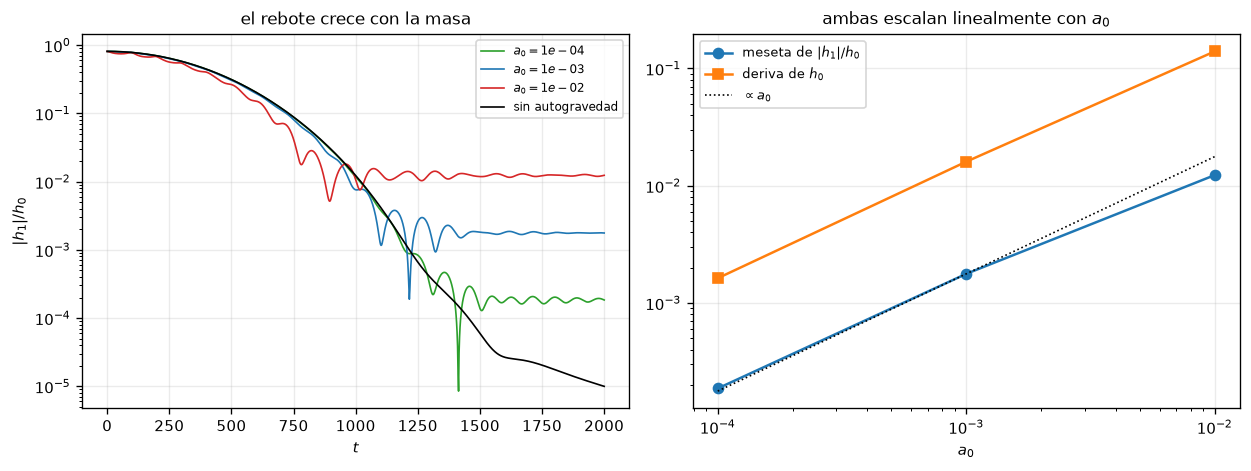

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
for a0, d, c in [(1e-4,'scan_a0_1e-4','tab:green'), (1e-3,'quad','tab:blue'),
                 (1e-2,'scan_a0_1e-2','tab:red')]:
    a = np.loadtxt(os.path.join(DATA, d, 'hk1.tl'))
    axes[0].semilogy(a[:,0], a[:,2]/a[0,1], lw=1, color=c, label=f'$a_0={a0:.0e}$')
a = np.loadtxt(os.path.join(DATA, 'quad_nosg', 'hk1.tl'))
axes[0].semilogy(a[:,0], a[:,2]/a[0,1], 'k-', lw=1, label='sin autogravedad')
axes[0].set_xlabel('$t$'); axes[0].set_ylabel('$|h_1|/h_0$'); axes[0].legend(fontsize=7)
axes[0].set_title('el rebote crece con la masa', fontsize=10)

axes[1].loglog(A, M, 'o-', label='meseta de $|h_1|/h_0$')
axes[1].loglog(A, Dh, 's-', label='deriva de $h_0$')
axes[1].loglog(A, np.array(A)*M[1]/A[1], 'k:', lw=1, label=r'$\propto a_0$')
axes[1].set_xlabel('$a_0$'); axes[1].legend(fontsize=8)
axes[1].set_title('ambas escalan linealmente con $a_0$', fontsize=10)
fig.tight_layout()

**Escala linealmente con $a_0$**: pendientes $+0.91$ para la meseta y $+0.97$ para la
deriva de $h_0$, frente al $+1$ de una respuesta lineal. Y el mínimo se adelanta al
subir la masa —$t=1414$, $1216$, $896$—, que es lo que hace una respuesta colectiva:
cuanto más fuerte es el acoplamiento, antes domina sobre el decaimiento cinemático.

**El rebote es físico.** Es la respuesta colectiva del sistema autogravitante: el
estado inicial es un equilibrio del isócrono solo, y al encender la gravedad propia el
sistema se reajusta. Una vez que el phase mixing ha borrado la estructura angular
impuesta, lo que queda es esa respuesta.

### 3.3 Por qué el Monte Carlo me había engañado

En la primera pasada del análisis concluí lo contrario: que el rebote era ruido
amplificado. Ese error merece quedar escrito, porque es instructivo.

El argumento era el escalado en $N$ **del Monte Carlo**, que daba pendiente $-0.28$ y
se ajustaba bien a *ruido más una componente independiente de $N$*. Pero el nivel
físico es $1.77\times10^{-3}\,h_0 = 4.4\times10^{-9}$, y las mesetas del Monte Carlo a
$N=10^3,10^4,10^5$ valían $5.9\times10^{-8}$, $2.4\times10^{-8}$ y $1.6\times10^{-8}$:
**las tres por encima de la señal**. El Monte Carlo estaba dominado por su propio ruido
en todo el rango, y lo que yo interpretaba como "una componente que $N$ no elimina" era
sólo una extrapolación mala desde tres puntos que todavía no habían llegado al suelo.

La cuadratura, con mucho menos ruido de muestreo, ya resuelve la señal con $N=10^3$.
Correr **los dos esquemas** no era redundancia: era lo que permitía distinguirlos.

## 4. Qué queda establecido

1. **La energía se conserva a $5\times10^{-4}$** con autogravedad, frente a
   $7\times10^{-11}$ con fondo fijo: el depósito en malla rompe el carácter simpléctico.
   Esa cifra es proporcional a $a_0$ y es el suelo de confianza de cada corrida.

2. **$h_0$ deriva linealmente con la masa**, un $1.6\%$ para $a_0=10^{-3}$. Es la medida
   directa de cuánto deja de conservarse $J$ al añadir el potencial propio.

3. **El decaimiento inicial es phase mixing, no Landau damping.** La envolvente es
   gaussiana en $t$ ($R^2=1.00000$ en el control), no exponencial ($R^2=0.938$).

4. **La autogravedad acelera ese decaimiento un $2.5\%$**, coherentemente en los dos
   esquemas de muestreo.

5. **El rebote tardío es la respuesta colectiva del sistema.** Es insensible a la
   resolución de la malla, al orden del B-spline y al número de partículas —tres dígitos
   iguales con cien veces más partículas— y escala linealmente con $a_0$. El solver de
   Poisson se verificó aparte: fuera de la distribución reproduce $-M(r)/r^2$ con un
   error del $0.7\%$, que es el de la propia comprobación.

### Lo que sigue abierto

El rebote está caracterizado pero no explicado: sabemos que es colectivo y lineal en
$a_0$, no qué modo es. Identificarlo pediría resolver el problema de autovalores del
sistema linealizado, o al menos medir con cuidado su frecuencia y su ritmo de
crecimiento en corridas más largas, con $t_{\max}$ muy por encima de los $2000$ de aquí.

Y el régimen sigue siendo el de perturbación débil. Con $a_0=10^{-2}$ la deriva de $h_0$
ya es del $14\%$, señal de que las variables ángulo-acción del isócrono empiezan a no
describir las órbitas. Ir más arriba obliga a replantear el diagnóstico entero.